## Pre-training Framework


In [ ]:
# NervousSystem_Parkinsons_Other_Movement

# NervousSystem_Epilepsy_Status_Epilepticus

# NervousSystem_Other_Neuro

# NervousSystem_Cerebrovascular

# ICD_F32_Depressive_Episode

# Psychopathology_Mood_Affective

# Psychopathology_Substance_Use

# NervousSystem_Sleep_Disorders 

In [67]:

# Select Target
TARGET_COLUMN = 'ASD'  
LOAD_WEIGHTS = 'weights_Neuro_DisorderX.pth' 


# Data paths 
BASE_DIR = '/home/jaizor/jaizor/xtra/notebooks/UKBB/dataset/abide'
DATA_PATH = f"{BASE_DIR}/fmri_{TARGET_COLUMN}.npz"
PHENO_PATH = f"{BASE_DIR}/pheno_{TARGET_COLUMN}.csv"
ROI_NAMES = "/home/jaizor/jaizor/xtra/notebooks/UKBB/dataset/roi_labels.csv"

# Weights directory
WEIGHTS_DIR = '/home/jaizor/jaizor/xtra/notebooks/UKBB/scripts/weights'
WEIGHT_PATH = f"{WEIGHTS_DIR}/{LOAD_WEIGHTS}"

STEP 1: Loading Data for Target = 'ASD'
✓ Loaded phenotype: (585, 4)
✅ Loaded 414 ROI labels from /home/jaizor/jaizor/xtra/notebooks/UKBB/dataset/roi_labels.csv
✓ Loaded fMRI: (585, 150, 414)
  Subjects: 585
  Timepoints: 150
  Brain regions: 414
  ROI labels: 414
✓ All required columns present

STEP 2: Preparing Data Loaders
🧼 Cohort: 585 subjects (271 cases, 314 controls, 46.3% prevalence)
✅ Splits → Train: 409, Val: 88, Test: 88

📊 Dataset Meta
  target: ASD
  n_total: 585
  n_positive: 271
  prevalence: 0.4632478654384613
  feature_dim: 414
  n_train: 409
  n_val: 88
  n_test: 88

STEP 3: Initializing BBTransformer 
✓ Model created on CPU with 25,878,114 parameters

STEP 3.5: Loading Pretrained Weights
Attempting SAFE load (on CPU first): /home/jaizor/jaizor/xtra/notebooks/UKBB/scripts/weights/weights_Neuro_DisorderX.pth
✓ Successfully loaded 88 layers from: /home/jaizor/jaizor/xtra/notebooks/UKBB/scripts/weights/weights_Neuro_DisorderX.pth

STEP 4: Fine-tuning with Ranger21


Early stopping triggered at epoch 168 (loss: 0.8747)

✅ Fine-tuning complete!
✓ Saved SAFE weights (weights_only=True compatible) to: weights/weights_ASD.pth

STEP 5: Test Set Evaluation



🧪 Performance Metrics:
  Accuracy:  0.5909
  Precision: 0.5581
  Recall:    0.5854
  F1 Score:  0.5714
  ROC-AUC:   0.5906

📊 Confusion Matrix:
[[28 19]
 [17 24]]


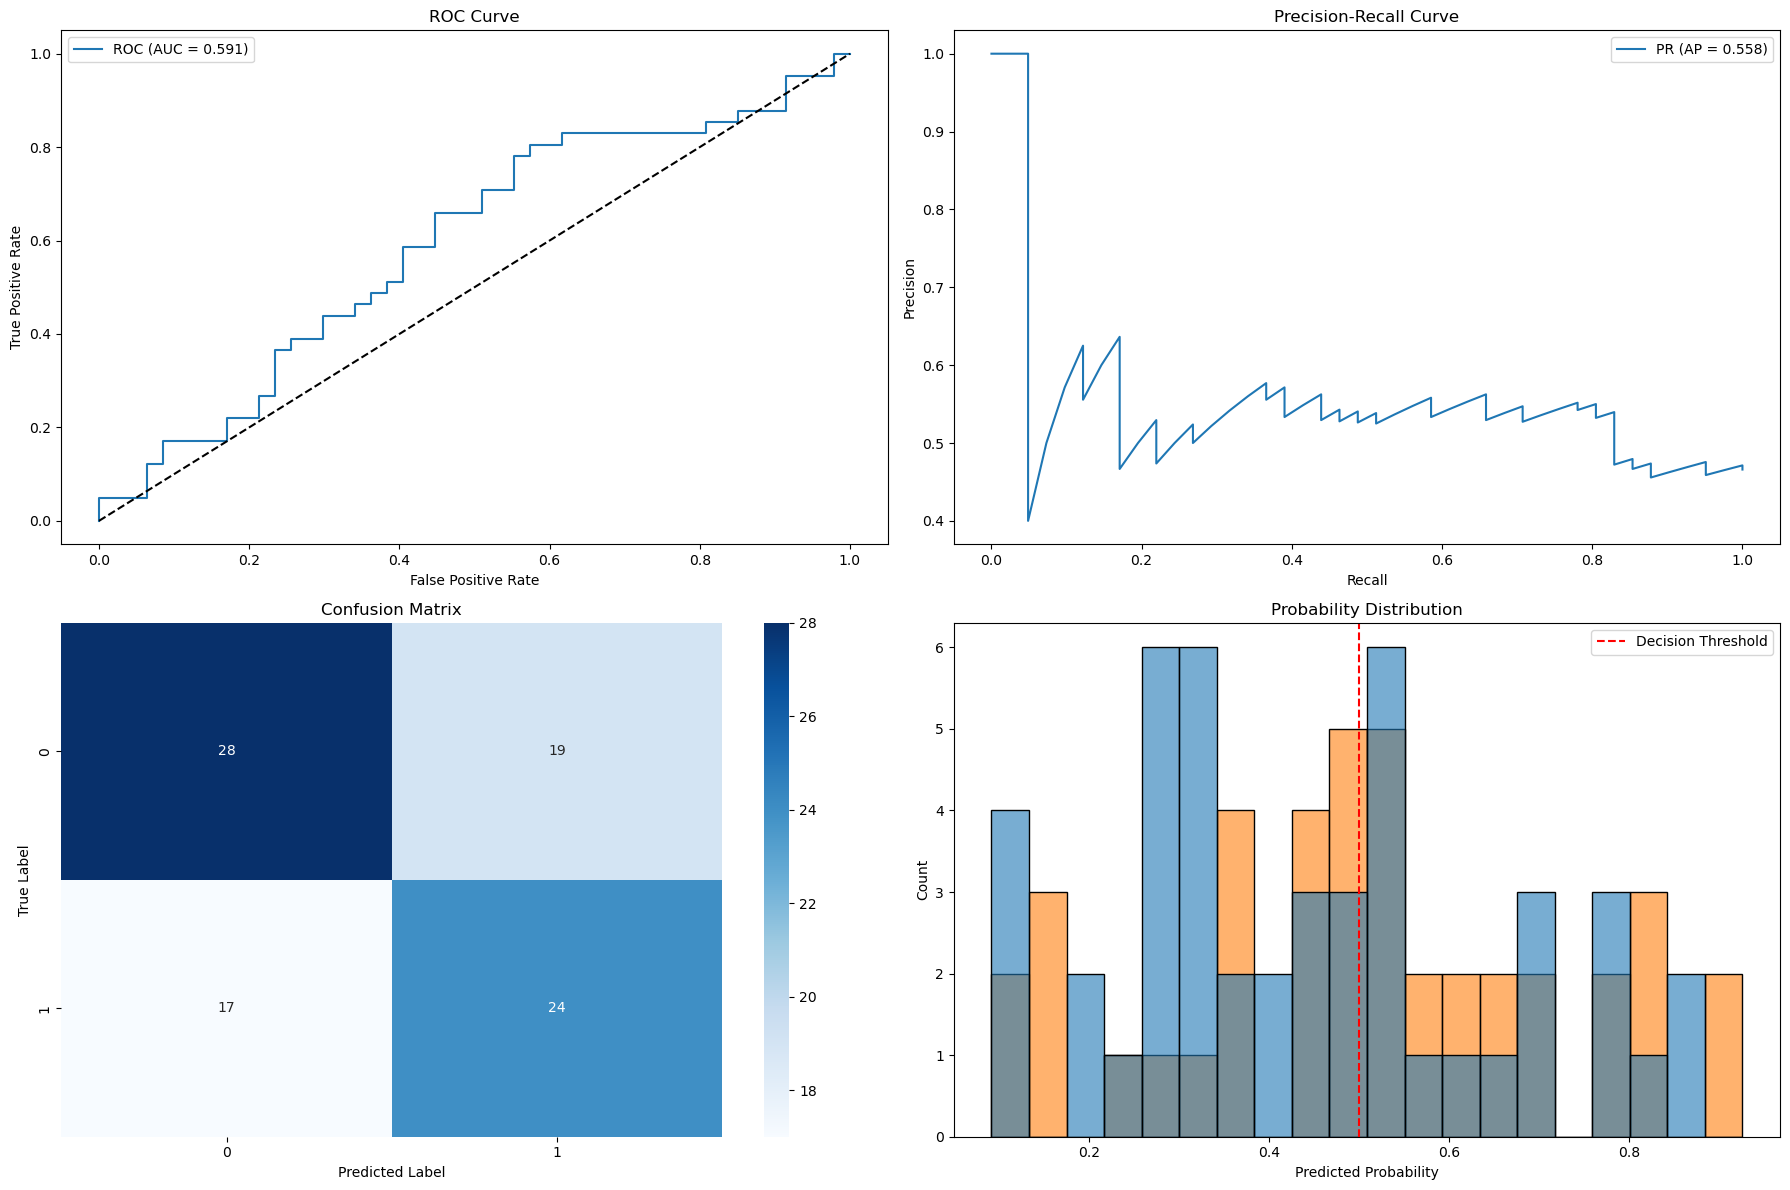

✅ Saved evaluation plots to results/ASD_results.png

✅ TRAINING & EVALUATION COMPLETE
→ Target: ASD
→ Architecture: Enhanced BBTransformer (Sex-tuned)
→ Optimizer: Ranger21
→ Weights: Saved to weights/weights_{TARGET_COLUMN}.pth


In [ ]:
# ===============================================
# Execute Script
# ===============================================

import os
import gc
import torch
import numpy as np
import pandas as pd
import bbtransformer as bbt
import matplotlib.pyplot as plt


from bbt import (
    prepare_fmri_data,
    train_model,
    evaluate_model,
    load_roi_names,
    create_bbtransformer,
    save_model_weights,
    load_model_weights
)


# Ensure dirs exist
os.makedirs('weights', exist_ok=True)
os.makedirs('results', exist_ok=True)


# ===============================================
# STEP 1: Load Data
# ===============================================

print("="*60)
print(f"STEP 1: Loading Data for Target = '{TARGET_COLUMN}'")
print("="*60)

pheno = pd.read_csv(PHENO_PATH)
print(f"✓ Loaded phenotype: {pheno.shape}")

features = np.load(DATA_PATH)
data = features['data']
subject_ids = features['subject_ids']

roi_names = load_roi_names(ROI_NAMES)
print(f"✓ Loaded fMRI: {data.shape}")
print(f"  Subjects: {len(subject_ids)}")
print(f"  Timepoints: {data.shape[1]}")
print(f"  Brain regions: {data.shape[2]}")
print(f"  ROI labels: {len(roi_names)}")

# Note: ext_column must exist and be binary (0/1)
required_columns = [TARGET_COLUMN, 'Age', 'Sex']  
missing = [col for col in required_columns if col not in pheno.columns]
if missing:
    raise ValueError(f"❌ Missing columns: {missing}")
print("✓ All required columns present")

# ==============================================
# STEP 2: Prepare Data Loaders
# ===============================================

print("\n" + "="*60)
print("STEP 2: Preparing Data Loaders")
print("="*60)


train_loader, val_loader, test_loader, metadata = prepare_fmri_data(
    data_path=DATA_PATH,
    pheno_path=PHENO_PATH,
    target_column=TARGET_COLUMN,
    age_column='Age',
    ext_column='Sex',  # ← Must be binary and match training config of pretrained weights
    batch_size=64,
    train_split=0.7,
    val_split=0.15,
    test_split=0.15,
    random_seed=42
)

print("\n📊 Dataset Meta")
for key, value in metadata.items():
    if key not in ['age_mean', 'age_std']:
        print(f"  {key}: {value}")


# ===============================================
# STEP 3: Initialize Model with Pretuned Architecture
# ===============================================

print("\n" + "="*60)
print("STEP 3: Initializing BBTransformer ")
print("="*60)



# 🔥 CRITICAL: Clear GPU memory from previous runs
torch.cuda.empty_cache()
gc.collect()

# ✅ Exact best hyperparameters from your Optuna Sex run
BEST_HP = {
    'feature_dim': metadata['feature_dim'],
    'num_classes': 1,
    'embed_dim': 512,
    'num_heads': 8,
    'num_layers': 6,
    'dropout_input': 0.271037581013532,
    'dropout_attn': 0.14600627822960482,
    'dropout_ffn': 0.27515967497010174,
    'dropout_classifier': 0.029054607960590395,
    'dropout_temporal': 0.1670895241114272,
    'embed_dim_age': 32,
    'embed_dim_ext': 16,
    'patch_size': 3,
    'patch_embed_ratio': 0.5,
    'temp_attn_hidden': 128,
    'n_kv_heads': 4,
    'return_attn_weights': False
}

# Create model on CPU first to avoid OOM during init
model = create_bbtransformer(BEST_HP)
print(f"✓ Model created on CPU with {model.count_parameters():,} parameters")


# ===============================================
# STEP 3.5: Load Pretrained Sex Weights (Memory-Safe)
# ===============================================

print("\n" + "="*60)
print("STEP 3.5: Loading Pretrained Weights")
print("="*60)


# Pass as list
success = load_model_weights(model, device='cpu', weight_paths=[WEIGHT_PATH])
if not success:
    raise RuntimeError("❌ Failed to load pretrained weights.")



# ===============================================
# STEP 4: Train (Fine-tune) with Ranger21
# ===============================================

print("\n" + "="*60)
print("STEP 4: Fine-tuning with Ranger21")
print("="*60)

trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=10000,
    lr=1.700152328841238e-05,
    weight_decay=2.3798658050870825e-05,
    patience=90,
    T_0=60,
    eta_min=1e-7  # ← highly recommended for cosine annealing
)

print("\n✅ Fine-tuning complete!")


# ===============================================
# STEP 4.5: Save Final Model Weights
# ===============================================

save_model_weights(
    trained_model,
    target_name=TARGET_COLUMN,
    safe_format=True
)



# ===============================================
# STEP 5: Evaluate on Test Set
# ===============================================

print("\n" + "="*60)
print("STEP 5: Test Set Evaluation")
print("="*60)

metrics, probs, targets = evaluate_model(trained_model, test_loader)

print("\n🧪 Performance Metrics:")
print(f"  Accuracy:  {metrics['accuracy']:.4f}")
print(f"  Precision: {metrics['precision']:.4f}")
print(f"  Recall:    {metrics['recall']:.4f}")
print(f"  F1 Score:  {metrics['f1']:.4f}")
print(f"  ROC-AUC:   {metrics['roc_auc']:.4f}")

print("\n📊 Confusion Matrix:")
print(metrics['confusion_matrix'])

plot_results(metrics, probs, targets, save_path=f'results/{TARGET_COLUMN}_results.png')


'''
# ===============================================
# STEP 6: Permutation Importance → CSV
# ===============================================

print("\n" + "="*60)
print("STEP 6: Permutation Importance (CSV)")
print("="*60)

importance_scores = calculate_permutation_importance(
    trained_model,
    val_loader,
    feature_dim=metadata['feature_dim'],
    n_repeats=1,
    seed=42,
    target_name=TARGET_COLUMN
)

save_top_importance_to_csv(
    importance_scores,
    roi_names=roi_names,
    target_name=TARGET_COLUMN,
    top_n=30,
    save_path=f'results/importance_{TARGET_COLUMN}.csv'
)

plot_brain_importance(
    importance_scores,
    roi_names=roi_names,
    top_n=30,
    save_path=f'results/importance_{TARGET_COLUMN}_plot.png'
)

print("✅ Permutation importance saved.")
'''

# ===============================================
# FINAL
# ===============================================

print("\n" + "="*60)
print("✅ TRAINING & EVALUATION COMPLETE")
print(f"→ Target: {TARGET_COLUMN}")
print("→ Architecture: Enhanced BBTransformer (Sex-tuned)")
print("→ Optimizer: Ranger21")
print("→ Weights: Saved to weights/weights_{TARGET_COLUMN}.pth")
print("="*60)